# Cross-Modal GradCAM for MRL CLIP

This Notebool allow you generate the GradCAM to Visualize the model's focus on regions in the image based on a **Text Query** (input sentence), and compare the change in focus as the dimensionality changes according to **Matryoshka Representation Learning (MRL)**.

**Note:** Running this notebook requires the installation of the following libraries: `transformers`, `grad-cam`, `matplotlib`, `pillow`, `requests`.

In [4]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests

# point to the folder that contains the model code
sys.path.append('../ai-worker/')
from model import MRL_CrossModal_Model
from transformers import CLIPProcessor

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

%matplotlib inline
%config InlineBackend.figure_format='retina'

## 1. Initialize the Model and Load Checkpoint

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Initialize MRL Cross-Modal Model (default CLIP ViT-B/32)
mrl_model = MRL_CrossModal_Model().to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the checkpoint if it exists
ckpt_path = "../ai-worker/checkpoints/mrl_v3_best.pt"
if os.path.exists(ckpt_path):
     mrl_model.load_state_dict(torch.load(ckpt_path, map_location=device))
     print("Loaded checkpoint successfully!")

mrl_model.eval()

Using device: cpu


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 29776.02it/s]


Loaded checkpoint successfully!


MRL_CrossModal_Model(
  (clip): CLIPModel(
    (text_model): CLIPTextModel(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, b

## 2. Wrap model to compute Cosine Similarity (purpose of GradCAM)

In [6]:
class CLIPSimilarityWrapper(torch.nn.Module):
    def __init__(self, model, text_embeds, mrl_dim=768):
        super().__init__()
        self.model = model
        self.text_embeds = text_embeds
        self.mrl_dim = mrl_dim
        
    def forward(self, images):
        # Extract image features (Note: Gradient will flow through this section)
        img_embeds = self.model.extract_image_features(images, dim=self.mrl_dim)
        
        # Normalize cosine similarity
        img_embeds = torch.nn.functional.normalize(img_embeds, dim=-1)
        txt_embeds = torch.nn.functional.normalize(self.text_embeds, dim=-1)
        
        # Calculate similarity (Dot product of 2 normalized vectors)
        # The result returned has the shape [batch, 1], and GradCAM will automatically understand this as the point to maximize.
        sim = (img_embeds * txt_embeds).sum(dim=-1, keepdim=True)
        return sim

## 3. Declare Image and Text Query

In [7]:
# load img from your device (local path)
img_url = r"D:\Pre-thesis\Thesis Dataset-20260617T002927Z-3-002\Thesis Dataset\data_images\4740.jpg"
image = Image.open(img_url).convert("RGB")

# text query for GradCAM
text_query = "a black adidas shoe with white sole"

# Image and text preprocessing
inputs = processor(text=[text_query], images=image, return_tensors="pt", padding=True).to(device)

# take the text embedding from the model (no gradient needed)
with torch.no_grad():
    full_text_embeds = mrl_model.extract_text_features(inputs.input_ids, inputs.attention_mask)

# Prepare the RGB image (224x224) normalized to 0-1 for heatmap overlay
rgb_img = np.array(image.resize((224, 224)), dtype=np.float32) / 255.0

## 4. Configure GradCAM for Vision Transformer (ViT) and draw Heatmap

Original Image


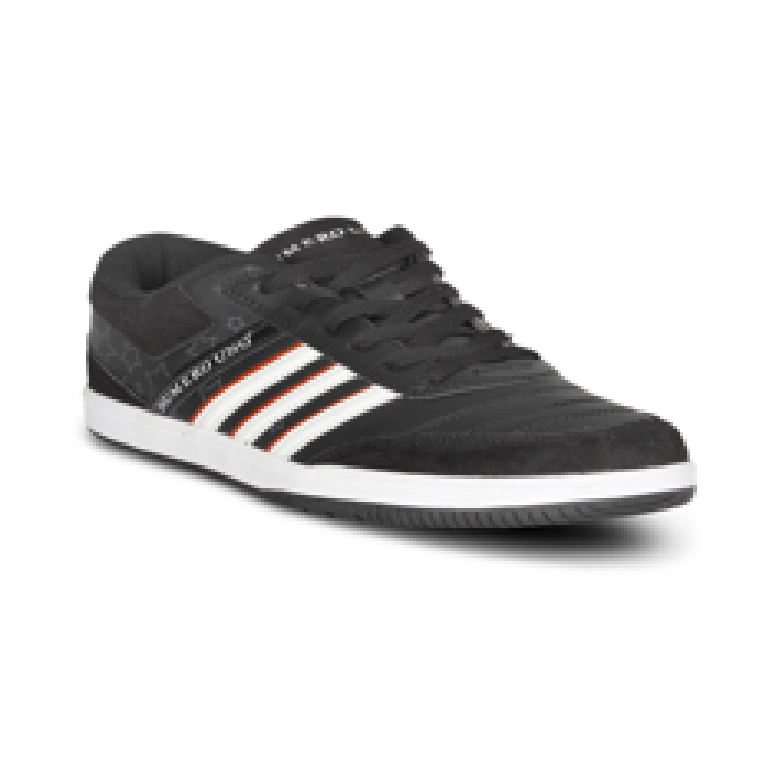

--------------------------------------------------
Feature Dimensionality:	 16
Text Query:		 a black adidas shoe with white sole
Cosine Similarity:	 0.7196


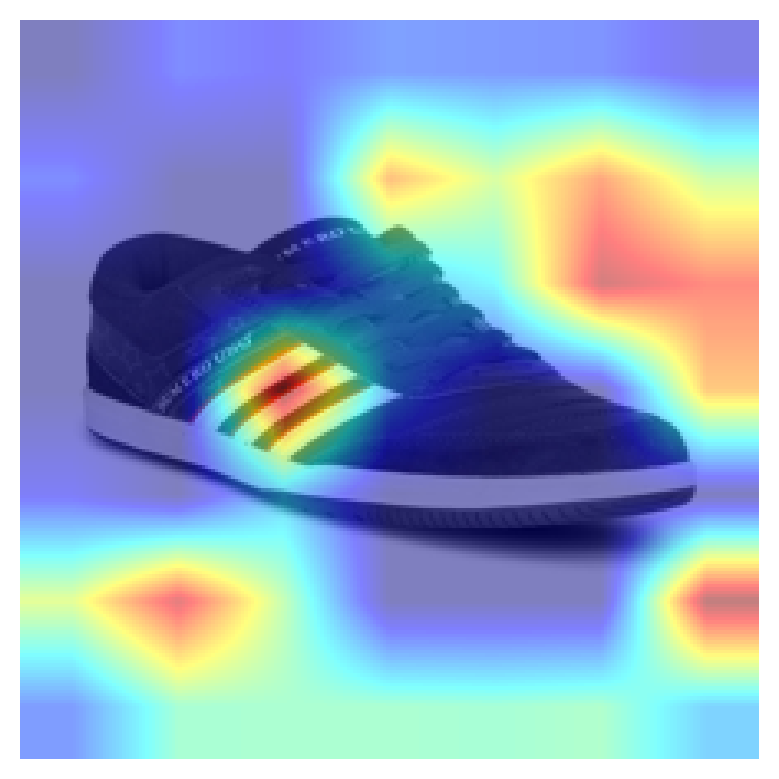

--------------------------------------------------
Feature Dimensionality:	 64
Text Query:		 a black adidas shoe with white sole
Cosine Similarity:	 0.6149


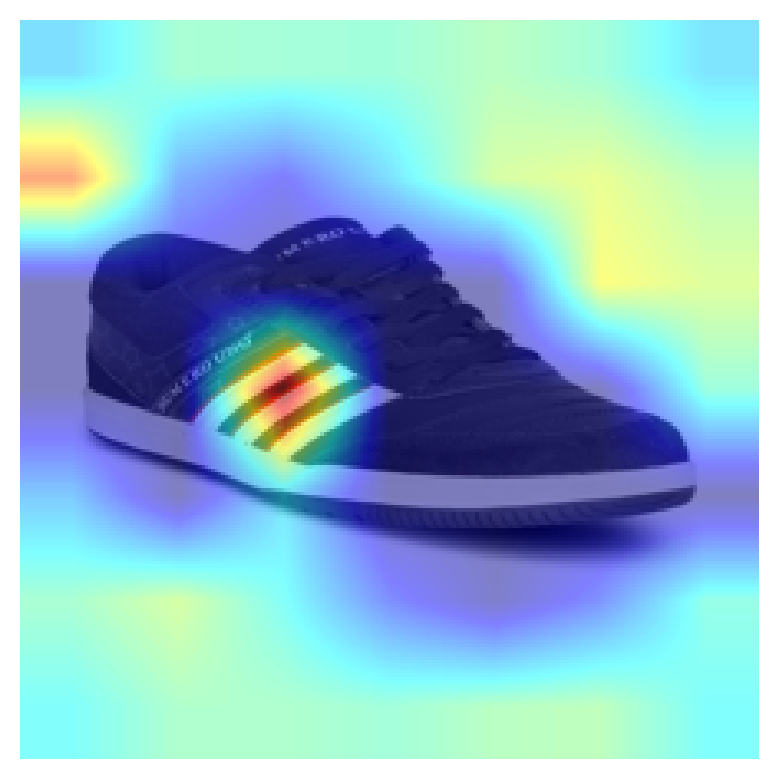

--------------------------------------------------
Feature Dimensionality:	 256
Text Query:		 a black adidas shoe with white sole
Cosine Similarity:	 0.5549


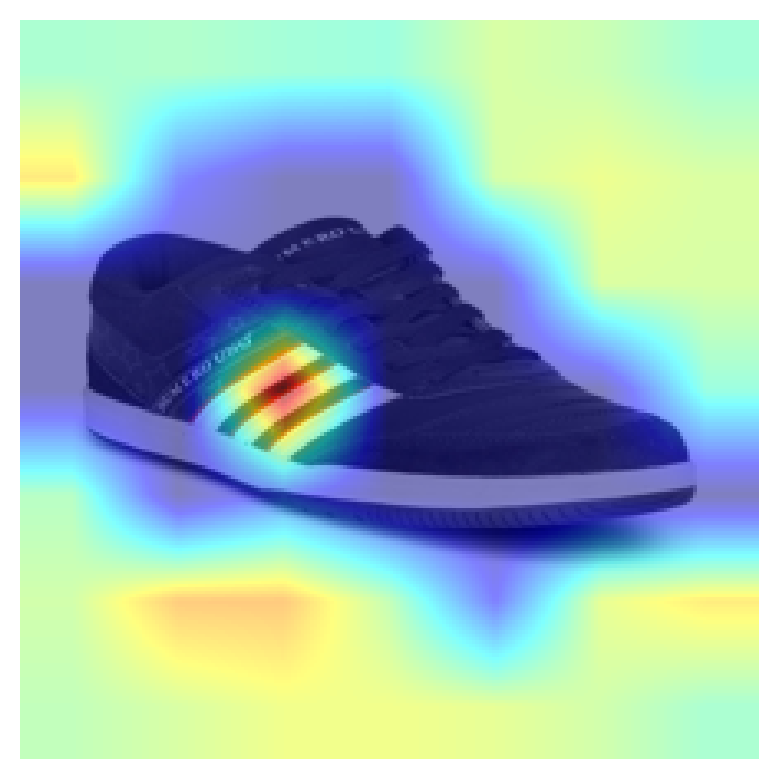

--------------------------------------------------
Feature Dimensionality:	 512
Text Query:		 a black adidas shoe with white sole
Cosine Similarity:	 0.4951


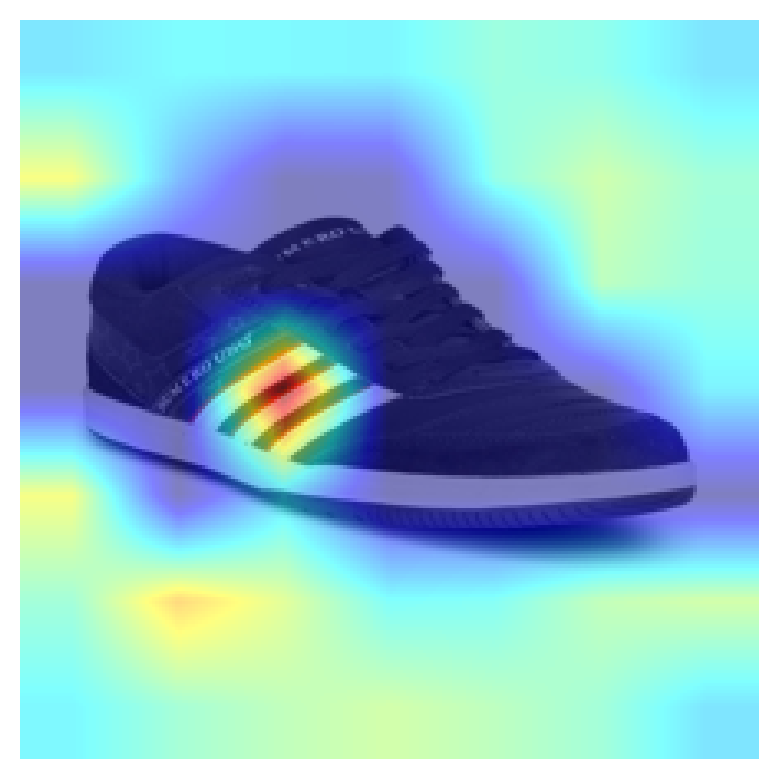

--------------------------------------------------
Feature Dimensionality:	 768
Text Query:		 a black adidas shoe with white sole
Cosine Similarity:	 0.4951


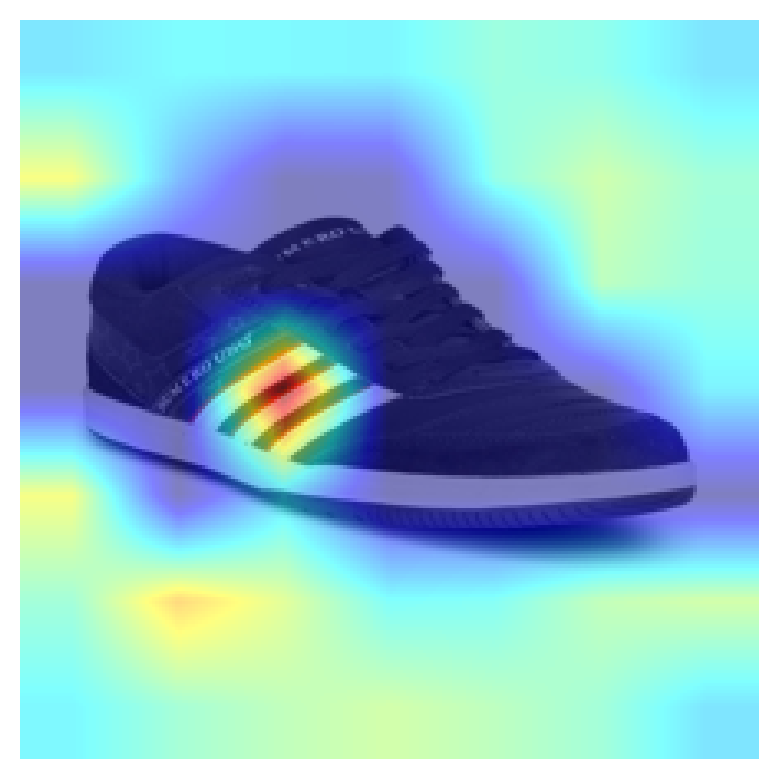

In [11]:
# The following example shows how the focus of the model shifts across different MRL dimensions.
print("Original Image")
plt.imshow(rgb_img)
plt.axis("off")
plt.show()

img_tensor = inputs.pixel_values  # shape: [1, 3, 224, 224]
mrl_dims = [16, 64, 256, 512, 768]

for dim in mrl_dims:
    txt_embeds_dim = full_text_embeds[:, :dim]
    wrapper = CLIPSimilarityWrapper(mrl_model, txt_embeds_dim, mrl_dim=dim)
    
    # Compute Cosine Similarity Score
    with torch.no_grad():
        score = wrapper(img_tensor).item()
    
    cam = GradCAM(model=wrapper, 
                  target_layers=target_layers, 
                  reshape_transform=reshape_transform)
                  
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    print("-" * 50)
    print("Feature Dimensionality:\t", dim)
    print("Text Query:\t\t", text_query)
    print(f"Cosine Similarity:\t {score:.4f}")
    
    plt.imshow(cam_image)
    plt.axis("off")
    plt.show()


# Analysis of Cosine Similarity Across MRL Dimensions

Although the cosine similarity between the query and the corresponding image decreases as the MRL embedding dimension increases, this phenomenon should not be interpreted as a degradation in retrieval performance. The cosine similarity values obtained for different MRL dimensions are computed in distinct embedding subspaces, making their absolute values not directly comparable.

Specifically, the 16-dimensional embedding produces the highest cosine similarity (0.7196), while the similarity gradually decreases to approximately 0.4951 for both the 512- and 768-dimensional embeddings. This trend is expected because Matryoshka Representation Learning (MRL) optimizes nested embedding spaces rather than preserving identical similarity distributions across dimensions. Each truncated embedding is independently trained to maintain retrieval capability under its dimensionality constraint, resulting in different feature distributions and cosine similarity scales.

More importantly, image retrieval performance depends primarily on the relative ranking of candidate images rather than the absolute cosine similarity value. A lower similarity score does not necessarily indicate poorer semantic alignment if the similarity gap between the correct image and incorrect candidates becomes larger. In other words, retrieval quality is determined by the discriminative ability of the embedding space instead of the magnitude of the similarity score itself.

This observation is also consistent with the retrieval evaluation metrics obtained in our experiments. While cosine similarity decreases with increasing embedding dimensions, Recall@K and mAP consistently improve. This suggests that higher-dimensional MRL embeddings capture richer semantic information and provide better separation between relevant and irrelevant images, leading to more accurate retrieval despite lower absolute similarity values.

Furthermore, the identical cosine similarity observed at 512 and 768 dimensions (0.4951) indicates that most discriminative semantic information has already been preserved within the first 512 dimensions. This finding is further supported by the Grad-CAM visualizations, where the attention maps for 512 and 768 dimensions are nearly identical, both focusing primarily on the Adidas stripes and the white sole specified in the text query. Consequently, increasing the embedding dimension beyond 512 offers limited additional benefit for this retrieval example while incurring higher storage and computational costs.

The Grad-CAM visualizations further support this interpretation. As the embedding dimension increases, the attention maps become progressively more concentrated on semantically relevant regions, particularly the Adidas logo (three stripes) and the white sole described in the text query, while attention to background regions is significantly reduced. Although the cosine similarity decreases, the higher-dimensional embeddings exhibit stronger localization of discriminative features, explaining the improved retrieval accuracy observed in Recall@K and mAP.

In summary, the decreasing cosine similarity across MRL dimensions should not be interpreted as reduced semantic understanding. Instead, it reflects changes in the embedding space induced by Matryoshka Representation Learning. Higher-dimensional embeddings provide better feature discrimination and more reliable ranking performance, which ultimately leads to superior retrieval accuracy despite lower absolute cosine similarity values.